In [ ]:
import os
import yaml
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set the base directory to the project root (one level up from /notebooks)
base_dir = Path("..").resolve()
dataset_dir = base_dir / "data" / "processed" / "yolo_dataset"
dataset_yaml = dataset_dir / "data.yaml"

# Load the class names from data.yaml
with open(dataset_yaml, 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
print("Classes mapped in data.yaml:", classes)


Classes mapped in data.yaml: {0: 'Weapon', 1: 'Person', 2: 'Confuser'}


Annotation Counts per Split:


,Weapon,Person,Confuser
Train,27655,112,32865
Val,3361,9,3989
Test,3388,17,4217


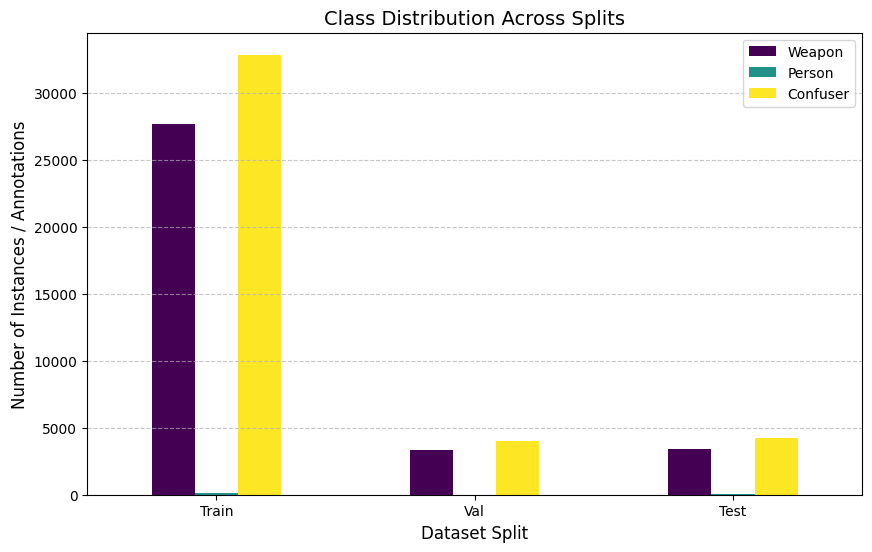

In [3]:
def get_class_counts(split='train'):
    # Path to the labels directory for the given split
    split_labels_dir = dataset_dir / split / "labels"
    label_files = glob.glob(str(split_labels_dir / "*.txt"))
    
    # Initialize counts
    counts = {v: 0 for k, v in classes.items()}
    
    for file in label_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                # YOLO format: <class_id> <x> <y> <w> <h>
                class_id = int(line.split()[0])
                counts[classes[class_id]] += 1
                
    return counts

# Gather counts for all splits
train_counts = get_class_counts('train')
val_counts = get_class_counts('val')
test_counts = get_class_counts('test')

# Create a DataFrame for easy viewing
df_counts = pd.DataFrame([train_counts, val_counts, test_counts], index=['Train', 'Val', 'Test'])
print("Annotation Counts per Split:")
display(df_counts)

# Plot the distributions
df_counts.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='viridis')
plt.title('Class Distribution Across Splits', fontsize=14)
plt.ylabel('Number of Instances / Annotations', fontsize=12)
plt.xlabel('Dataset Split', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
